In [1]:
from google.colab import drive
import os
import numpy as np
import torch

# Mount Google Drive
drive.mount("/content/drive")

# GPU check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU not available. Go to Runtime > Change runtime type > GPU")

# Same dataset file path used earlier
DATA_FILE = "/content/drive/MyDrive/CogAge/sensory_data_Atomic_Activities/HAR_PR_dataset_ver2/examples/Adeel_Bending_1_extracted/PhoneAccelerometer_Event_0.data"

# New save folder for Level 3 with Positional Encoding
SAVE_ROOT = "/content/drive/MyDrive/PR_Assignment1_Level3_PositionalEncoding/Adeel_Bending_1_PhoneAccelerometer_Event0"

os.makedirs(SAVE_ROOT, exist_ok=True)

print("\nDATA_FILE exists:", os.path.exists(DATA_FILE))
print("SAVE_ROOT exists:", os.path.exists(SAVE_ROOT))
print("SAVE_ROOT:", SAVE_ROOT)

Mounted at /content/drive
Using device: cuda
GPU name: Tesla T4

DATA_FILE exists: True
SAVE_ROOT exists: True
SAVE_ROOT: /content/drive/MyDrive/PR_Assignment1_Level3_PositionalEncoding/Adeel_Bending_1_PhoneAccelerometer_Event0


Load sensor data and create input matrix X

In [2]:
import pandas as pd
import numpy as np

# Load selected sensor file
df = pd.read_csv(DATA_FILE, sep=";", header=None)

print("File loaded successfully.")
print("Raw dataframe shape:", df.shape)

# First column = timestamp
# Remaining columns = x, y, z accelerometer values
X_raw = df.iloc[:, 1:].values.astype(np.float32)

print("X_raw shape:", X_raw.shape)

print("\nFirst 5 rows of raw sensor values:")
print(X_raw[:5])

print("\nMeaning:")
print("Rows = time-points")
print("Columns = x, y, z accelerometer features")

File loaded successfully.
Raw dataframe shape: (1007, 4)
X_raw shape: (1007, 3)

First 5 rows of raw sensor values:
[[-3.4519958  8.682159  -2.5914764]
 [-3.4519958  8.746796  -2.5483856]
 [-3.4304504  8.746796  -2.5268402]
 [-3.4639587  8.761169  -2.5268402]
 [-3.4831238  8.787506  -2.4957123]]

Meaning:
Rows = time-points
Columns = x, y, z accelerometer features


Normalize X and move to GPU

In [3]:
# Normalize X_raw for stable attention calculation

mean = X_raw.mean(axis=0, keepdims=True)
std = X_raw.std(axis=0, keepdims=True) + 1e-8

X_norm = (X_raw - mean) / std

# Convert to PyTorch tensor and move to GPU
X = torch.tensor(X_norm, dtype=torch.float32).to(device)

print("Original X_raw shape:", X_raw.shape)
print("Normalized X_norm shape:", X_norm.shape)
print("Torch X shape:", X.shape)
print("X device:", X.device)

print("\nOriginal feature means:")
print(mean)

print("\nOriginal feature std:")
print(std)

print("\nAfter normalization mean approx:")
print(X_norm.mean(axis=0))

print("\nAfter normalization std approx:")
print(X_norm.std(axis=0))

print("\nFirst 5 rows of normalized X:")
print(X[:5].detach().cpu().numpy())

Original X_raw shape: (1007, 3)
Normalized X_norm shape: (1007, 3)
Torch X shape: torch.Size([1007, 3])
X device: cuda:0

Original feature means:
[[-3.4633455  8.838707  -2.40563  ]]

Original feature std:
[[0.08219557 0.12610944 0.40360183]]

After normalization mean approx:
[2.6365733e-06 3.0911549e-06 3.9397071e-07]

After normalization std approx:
[0.9999999  0.9999998  0.99999994]

First 5 rows of normalized X:
[[ 0.13808139 -1.2413627  -0.46046948]
 [ 0.13808139 -0.7288219  -0.35370383]
 [ 0.40020514 -0.7288219  -0.30032098]
 [-0.00746041 -0.61484325 -0.30032098]
 [-0.24062432 -0.40600345 -0.22319564]]


Create Positional Encoding and Add to X

In [4]:
# Cell 4: Positional Encoding for time-series input

import math
import torch

N, D = X.shape   # N = time-points, D = features

PE = torch.zeros(N, D, device=device)

position = torch.arange(0, N, dtype=torch.float32, device=device).unsqueeze(1)

div_term = torch.exp(
    torch.arange(0, D, 2, dtype=torch.float32, device=device) * (-math.log(10000.0) / D)
)

# Even dimensions: sin
PE[:, 0::2] = torch.sin(position * div_term)

# Odd dimensions: cos
PE[:, 1::2] = torch.cos(position * div_term[:PE[:, 1::2].shape[1]])

# Add positional information to normalized input
X_pos = X + PE

print("Input X shape:", X.shape)
print("Positional Encoding PE shape:", PE.shape)
print("Position-aware input X_pos shape:", X_pos.shape)

print("\nFirst 5 rows of PE:")
print(PE[:5].detach().cpu().numpy())

print("\nFirst 5 rows of X_pos = X + PE:")
print(X_pos[:5].detach().cpu().numpy())

Input X shape: torch.Size([1007, 3])
Positional Encoding PE shape: torch.Size([1007, 3])
Position-aware input X_pos shape: torch.Size([1007, 3])

First 5 rows of PE:
[[ 0.          1.          0.        ]
 [ 0.841471    0.5403023   0.00215443]
 [ 0.90929747 -0.4161468   0.00430886]
 [ 0.14112    -0.9899925   0.00646326]
 [-0.7568025  -0.65364367  0.00861763]]

First 5 rows of X_pos = X + PE:
[[ 0.13808139 -0.24136269 -0.46046948]
 [ 0.9795524  -0.1885196  -0.3515494 ]
 [ 1.3095026  -1.1449687  -0.29601213]
 [ 0.13365959 -1.6048357  -0.29385772]
 [-0.9974268  -1.0596471  -0.214578  ]]


Create Q, K, V from X_pos

In [5]:
# Cell 5: Create Query, Key, Value from position-aware input X_pos

torch.manual_seed(42)

D_MODEL = X_pos.shape[1]   # 3 input features
D_K = 8                    # hidden dimension for Q, K, V

W_Q = torch.randn(D_MODEL, D_K, device=device) * 0.01
W_K = torch.randn(D_MODEL, D_K, device=device) * 0.01
W_V = torch.randn(D_MODEL, D_K, device=device) * 0.01

Q = X_pos @ W_Q
K = X_pos @ W_K
V = X_pos @ W_V

print("X_pos shape:", X_pos.shape)

print("\nW_Q shape:", W_Q.shape)
print("W_K shape:", W_K.shape)
print("W_V shape:", W_V.shape)

print("\nQ shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

print("\nFirst 5 rows of Q:")
print(Q[:5].detach().cpu().numpy())

print("\nFirst 5 rows of K:")
print(K[:5].detach().cpu().numpy())

print("\nFirst 5 rows of V:")
print(V[:5].detach().cpu().numpy())

X_pos shape: torch.Size([1007, 3])

W_Q shape: torch.Size([3, 8])
W_K shape: torch.Size([3, 8])
W_V shape: torch.Size([3, 8])

Q shape: torch.Size([1007, 8])
K shape: torch.Size([1007, 8])
V shape: torch.Size([1007, 8])

First 5 rows of Q:
[[ 0.00228374  0.00289416  0.00010502  0.00205829 -0.00930278  0.00279913
   0.00297758 -0.0124027 ]
 [ 0.00341709  0.02115704 -0.00135314  0.00900622 -0.02392016  0.00783652
  -0.0033561  -0.01669414]
 [-0.00138928  0.04086873  0.01441911  0.01469018 -0.02855587  0.00779859
   0.00507632 -0.03634016]
 [-0.00611397  0.0213341   0.02410288  0.00610069 -0.00547012 -0.00080685
   0.01785975 -0.03523834]
 [-0.00599656 -0.00952043  0.01761892 -0.00518302  0.01697446 -0.00751595
   0.01889556 -0.01469462]]

First 5 rows of K:
[[ 1.96101447e-03  1.75953773e-03 -4.53683519e-04  6.41253078e-03
   6.12791162e-03  2.61885603e-03  3.87585186e-03  2.52247299e-03]
 [ 2.70137936e-03  4.35303984e-04 -6.61068223e-03  1.15440739e-02
   7.93066993e-03 -6.71662111e-03  

Compute Attention Output

In [6]:
# Cell 6: Scaled Dot-Product Attention with Positional Encoding

scores_pe = (Q @ K.T) / torch.sqrt(torch.tensor(D_K, dtype=torch.float32, device=device))

attention_weights_pe = torch.softmax(scores_pe, dim=1)

level3_pe_output = attention_weights_pe @ V

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)

print("\nScores with PE shape:", scores_pe.shape)
print("Attention weights with PE shape:", attention_weights_pe.shape)
print("Level 3 PE output shape:", level3_pe_output.shape)

print("\nCheck first 5 row sums of attention weights:")
print(attention_weights_pe[:5].sum(dim=1).detach().cpu().numpy())

print("\nFirst 5 rows of Level 3 output with PE:")
print(level3_pe_output[:5].detach().cpu().numpy())

Q shape: torch.Size([1007, 8])
K shape: torch.Size([1007, 8])
V shape: torch.Size([1007, 8])

Scores with PE shape: torch.Size([1007, 1007])
Attention weights with PE shape: torch.Size([1007, 1007])
Level 3 PE output shape: torch.Size([1007, 8])

Check first 5 row sums of attention weights:
[1. 1. 1. 1. 1.]

First 5 rows of Level 3 output with PE:
[[-0.01126803 -0.00605861  0.0008348  -0.00364265  0.00889706  0.00457512
  -0.00061356 -0.01146364]
 [-0.01126586 -0.00605909  0.00083334 -0.00364356  0.00889632  0.00457587
  -0.00061334 -0.01146284]
 [-0.0112616  -0.00605998  0.00083079 -0.00364431  0.00889436  0.00457686
  -0.000613   -0.01146055]
 [-0.01126306 -0.00605951  0.00083197 -0.00364327  0.00889464  0.00457609
  -0.00061318 -0.01146077]
 [-0.01126778 -0.0060583   0.00083505 -0.00364193  0.00889654  0.00457464
  -0.00061359 -0.01146291]]


Level 3 with Positional Encoding Results

In [7]:
# Cell 7: Save all Level 3 with Positional Encoding results to Drive

import os
import json
import numpy as np

# Convert tensors to CPU numpy arrays before saving
X_np = X.detach().cpu().numpy()
PE_np = PE.detach().cpu().numpy()
X_pos_np = X_pos.detach().cpu().numpy()

W_Q_np = W_Q.detach().cpu().numpy()
W_K_np = W_K.detach().cpu().numpy()
W_V_np = W_V.detach().cpu().numpy()

Q_np = Q.detach().cpu().numpy()
K_np = K.detach().cpu().numpy()
V_np = V.detach().cpu().numpy()

scores_pe_np = scores_pe.detach().cpu().numpy()
attention_weights_pe_np = attention_weights_pe.detach().cpu().numpy()
level3_pe_output_np = level3_pe_output.detach().cpu().numpy()

# Save arrays
np.save(os.path.join(SAVE_ROOT, "X_raw.npy"), X_raw)
np.save(os.path.join(SAVE_ROOT, "X_normalized.npy"), X_np)
np.save(os.path.join(SAVE_ROOT, "positional_encoding_PE.npy"), PE_np)
np.save(os.path.join(SAVE_ROOT, "X_with_positional_encoding.npy"), X_pos_np)

np.save(os.path.join(SAVE_ROOT, "W_Q_PE.npy"), W_Q_np)
np.save(os.path.join(SAVE_ROOT, "W_K_PE.npy"), W_K_np)
np.save(os.path.join(SAVE_ROOT, "W_V_PE.npy"), W_V_np)

np.save(os.path.join(SAVE_ROOT, "Q_PE.npy"), Q_np)
np.save(os.path.join(SAVE_ROOT, "K_PE.npy"), K_np)
np.save(os.path.join(SAVE_ROOT, "V_PE.npy"), V_np)

np.save(os.path.join(SAVE_ROOT, "scores_PE.npy"), scores_pe_np)
np.save(os.path.join(SAVE_ROOT, "attention_weights_PE.npy"), attention_weights_pe_np)
np.save(os.path.join(SAVE_ROOT, "level3_output_PE.npy"), level3_pe_output_np)

# Save metadata
metadata_pe = {
    "assignment": "PR Assignment 1 - Level 3 with Positional Encoding",
    "dataset": "CogAge",
    "selected_folder": "Adeel_Bending_1_extracted",
    "selected_file": "PhoneAccelerometer_Event_0.data",
    "input_description": "timestamp column removed; x, y, z accelerometer values used",
    "X_raw_shape": list(X_raw.shape),
    "X_normalized_shape": list(X_np.shape),
    "PE_shape": list(PE_np.shape),
    "X_pos_formula": "X_pos = X + PE",
    "X_pos_shape": list(X_pos_np.shape),
    "Q_formula": "Q = X_pos W_Q",
    "K_formula": "K = X_pos W_K",
    "V_formula": "V = X_pos W_V",
    "attention_formula": "Attention(Q,K,V) = softmax((Q K^T) / sqrt(d_k)) V",
    "D_K": D_K,
    "W_Q_shape": list(W_Q_np.shape),
    "W_K_shape": list(W_K_np.shape),
    "W_V_shape": list(W_V_np.shape),
    "Q_shape": list(Q_np.shape),
    "K_shape": list(K_np.shape),
    "V_shape": list(V_np.shape),
    "scores_shape": list(scores_pe_np.shape),
    "attention_weights_shape": list(attention_weights_pe_np.shape),
    "output_shape": list(level3_pe_output_np.shape),
    "device_used": str(device)
}

with open(os.path.join(SAVE_ROOT, "metadata_level3_positional_encoding.json"), "w") as f:
    json.dump(metadata_pe, f, indent=4)

print("Level 3 with Positional Encoding files saved successfully.")
print("SAVE_ROOT:")
print(SAVE_ROOT)

print("\nSaved files:")
for item in os.listdir(SAVE_ROOT):
    print(item)

Level 3 with Positional Encoding files saved successfully.
SAVE_ROOT:
/content/drive/MyDrive/PR_Assignment1_Level3_PositionalEncoding/Adeel_Bending_1_PhoneAccelerometer_Event0

Saved files:
X_raw.npy
X_normalized.npy
positional_encoding_PE.npy
X_with_positional_encoding.npy
W_Q_PE.npy
W_K_PE.npy
W_V_PE.npy
Q_PE.npy
K_PE.npy
V_PE.npy
scores_PE.npy
attention_weights_PE.npy
level3_output_PE.npy
metadata_level3_positional_encoding.json


Attention Heatmap with Positional Encoding

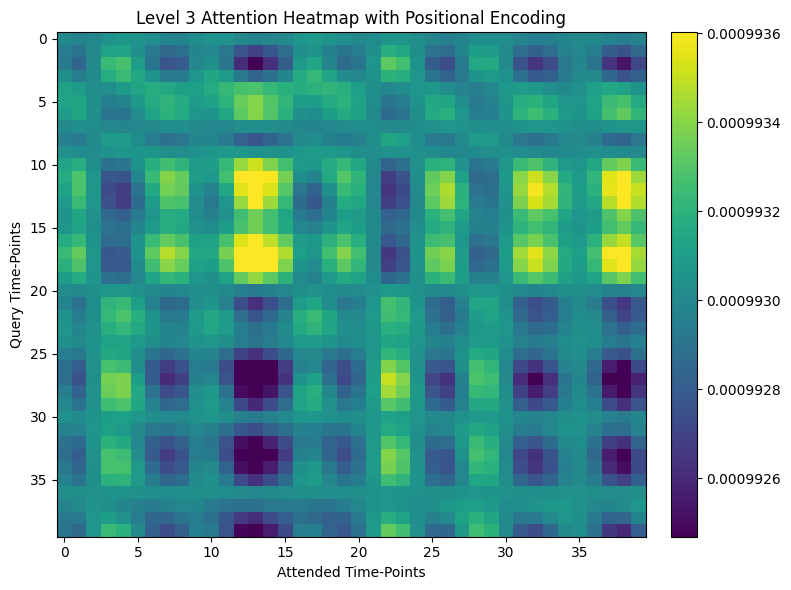

Attention heatmap saved successfully.
Heatmap path:
/content/drive/MyDrive/PR_Assignment1_Level3_PositionalEncoding/Adeel_Bending_1_PhoneAccelerometer_Event0/level3_attention_heatmap_with_PE_first_40.png


In [8]:
# Cell 8: Heatmap of Level 3 Attention Weights with Positional Encoding

import os
import numpy as np
import matplotlib.pyplot as plt

# Use first 40 time-points for clear visualization
N_VIEW = 40

attn_view = attention_weights_pe_np[:N_VIEW, :N_VIEW]

plt.figure(figsize=(8, 6))

vmin = np.percentile(attn_view, 1)
vmax = np.percentile(attn_view, 99)

im = plt.imshow(
    attn_view,
    aspect="auto",
    interpolation="nearest",
    vmin=vmin,
    vmax=vmax
)

plt.title("Level 3 Attention Heatmap with Positional Encoding")
plt.xlabel("Attended Time-Points")
plt.ylabel("Query Time-Points")
plt.colorbar(im, fraction=0.046, pad=0.04)

plt.tight_layout()

heatmap_path = os.path.join(SAVE_ROOT, "level3_attention_heatmap_with_PE_first_40.png")
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

print("Attention heatmap saved successfully.")
print("Heatmap path:")
print(heatmap_path)

Positional Encoding Visualization

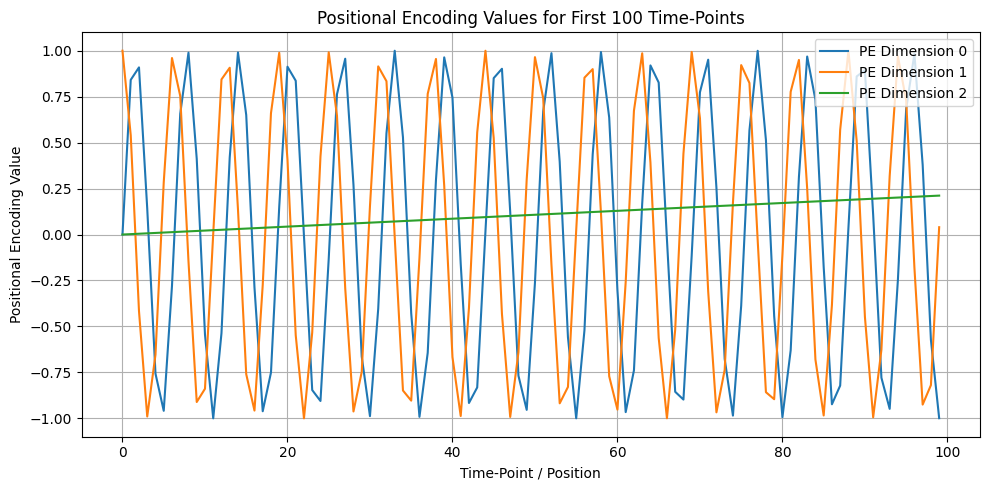

Positional encoding plot saved successfully.
Plot path:
/content/drive/MyDrive/PR_Assignment1_Level3_PositionalEncoding/Adeel_Bending_1_PhoneAccelerometer_Event0/positional_encoding_first_100_timepoints.png


In [9]:
# Cell 9: Visualize Positional Encoding Matrix

import os
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Show first 100 time-points of PE for all 3 dimensions
N_PE_VIEW = 100

plt.plot(PE_np[:N_PE_VIEW, 0], label="PE Dimension 0")
plt.plot(PE_np[:N_PE_VIEW, 1], label="PE Dimension 1")
plt.plot(PE_np[:N_PE_VIEW, 2], label="PE Dimension 2")

plt.title("Positional Encoding Values for First 100 Time-Points")
plt.xlabel("Time-Point / Position")
plt.ylabel("Positional Encoding Value")
plt.legend()
plt.grid(True)

plt.tight_layout()

pe_plot_path = os.path.join(SAVE_ROOT, "positional_encoding_first_100_timepoints.png")
plt.savefig(pe_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Positional encoding plot saved successfully.")
print("Plot path:")
print(pe_plot_path)

Compare X and X_pos

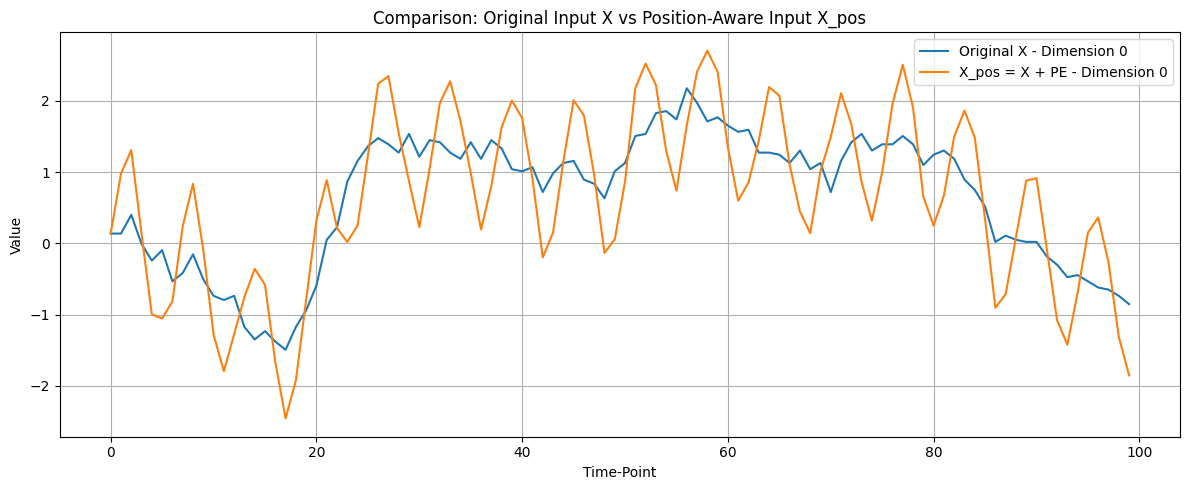

X vs X_pos comparison plot saved successfully.
Plot path:
/content/drive/MyDrive/PR_Assignment1_Level3_PositionalEncoding/Adeel_Bending_1_PhoneAccelerometer_Event0/X_vs_Xpos_dimension0_first_100.png


In [10]:
# Cell 10: Compare Original Normalized X and X with Positional Encoding

import os
import matplotlib.pyplot as plt

N_VIEW = 100   # first 100 time-points

plt.figure(figsize=(12, 5))

plt.plot(X_np[:N_VIEW, 0], label="Original X - Dimension 0")
plt.plot(X_pos_np[:N_VIEW, 0], label="X_pos = X + PE - Dimension 0")

plt.title("Comparison: Original Input X vs Position-Aware Input X_pos")
plt.xlabel("Time-Point")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.tight_layout()

x_compare_path = os.path.join(SAVE_ROOT, "X_vs_Xpos_dimension0_first_100.png")
plt.savefig(x_compare_path, dpi=300, bbox_inches="tight")
plt.show()

print("X vs X_pos comparison plot saved successfully.")
print("Plot path:")
print(x_compare_path)

Final Summary Table

In [11]:
# Cell 11: Create final summary table for Level 3 with Positional Encoding

import pandas as pd
import os

summary_table_pe = pd.DataFrame([
    {
        "Step": "Input Matrix",
        "Formula / Operation": "X = normalized sensor values",
        "Shape": str(tuple(X_np.shape)),
        "Meaning": "1007 time-points, 3 accelerometer features"
    },
    {
        "Step": "Positional Encoding",
        "Formula / Operation": "PE using sin/cos functions",
        "Shape": str(tuple(PE_np.shape)),
        "Meaning": "Adds time-position/order information"
    },
    {
        "Step": "Position-Aware Input",
        "Formula / Operation": "X_pos = X + PE",
        "Shape": str(tuple(X_pos_np.shape)),
        "Meaning": "Input now contains sensor values + position information"
    },
    {
        "Step": "Query Matrix",
        "Formula / Operation": "Q = X_pos W_Q",
        "Shape": str(tuple(Q_np.shape)),
        "Meaning": "Represents what each time-point is searching for"
    },
    {
        "Step": "Key Matrix",
        "Formula / Operation": "K = X_pos W_K",
        "Shape": str(tuple(K_np.shape)),
        "Meaning": "Represents what each time-point contains"
    },
    {
        "Step": "Value Matrix",
        "Formula / Operation": "V = X_pos W_V",
        "Shape": str(tuple(V_np.shape)),
        "Meaning": "Contains actual information used for output"
    },
    {
        "Step": "Attention Scores",
        "Formula / Operation": "Scores = Q K^T / sqrt(d_k)",
        "Shape": str(tuple(scores_pe_np.shape)),
        "Meaning": "Pairwise relation between all time-points"
    },
    {
        "Step": "Attention Weights",
        "Formula / Operation": "softmax(Scores)",
        "Shape": str(tuple(attention_weights_pe_np.shape)),
        "Meaning": "Normalized attention probabilities"
    },
    {
        "Step": "Final Output",
        "Formula / Operation": "Y = Attention Weights × V",
        "Shape": str(tuple(level3_pe_output_np.shape)),
        "Meaning": "Final Level 3 output with positional encoding"
    }
])

summary_csv_path = os.path.join(SAVE_ROOT, "level3_positional_encoding_summary_table.csv")
summary_table_pe.to_csv(summary_csv_path, index=False)

print("Final Level 3 with Positional Encoding Summary Table:")
display(summary_table_pe)

print("\nSummary table saved at:")
print(summary_csv_path)

Final Level 3 with Positional Encoding Summary Table:


,Step,Formula / Operation,Shape,Meaning
0,Input Matrix,X = normalized sensor values,"(1007, 3)","1007 time-points, 3 accelerometer features"
1,Positional Encoding,PE using sin/cos functions,"(1007, 3)",Adds time-position/order information
2,Position-Aware Input,X_pos = X + PE,"(1007, 3)",Input now contains sensor values + position in...
3,Query Matrix,Q = X_pos W_Q,"(1007, 8)",Represents what each time-point is searching for
4,Key Matrix,K = X_pos W_K,"(1007, 8)",Represents what each time-point contains
5,Value Matrix,V = X_pos W_V,"(1007, 8)",Contains actual information used for output
6,Attention Scores,Scores = Q K^T / sqrt(d_k),"(1007, 1007)",Pairwise relation between all time-points
7,Attention Weights,softmax(Scores),"(1007, 1007)",Normalized attention probabilities
8,Final Output,Y = Attention Weights × V,"(1007, 8)",Final Level 3 output with positional encoding



Summary table saved at:
/content/drive/MyDrive/PR_Assignment1_Level3_PositionalEncoding/Adeel_Bending_1_PhoneAccelerometer_Event0/level3_positional_encoding_summary_table.csv


Final summary table

In [12]:
# Cell 11: Create final summary table for Level 3 with Positional Encoding

import pandas as pd
import os

summary_table_pe = pd.DataFrame([
    {
        "Step": "Input Matrix",
        "Formula / Operation": "X = normalized sensor values",
        "Shape": str(tuple(X_np.shape)),
        "Meaning": "1007 time-points, 3 accelerometer features"
    },
    {
        "Step": "Positional Encoding",
        "Formula / Operation": "PE using sin/cos functions",
        "Shape": str(tuple(PE_np.shape)),
        "Meaning": "Adds time-position/order information"
    },
    {
        "Step": "Position-Aware Input",
        "Formula / Operation": "X_pos = X + PE",
        "Shape": str(tuple(X_pos_np.shape)),
        "Meaning": "Input now contains sensor values + position information"
    },
    {
        "Step": "Query Matrix",
        "Formula / Operation": "Q = X_pos W_Q",
        "Shape": str(tuple(Q_np.shape)),
        "Meaning": "Represents what each time-point is searching for"
    },
    {
        "Step": "Key Matrix",
        "Formula / Operation": "K = X_pos W_K",
        "Shape": str(tuple(K_np.shape)),
        "Meaning": "Represents what each time-point contains"
    },
    {
        "Step": "Value Matrix",
        "Formula / Operation": "V = X_pos W_V",
        "Shape": str(tuple(V_np.shape)),
        "Meaning": "Contains actual information used for output"
    },
    {
        "Step": "Attention Scores",
        "Formula / Operation": "Scores = Q K^T / sqrt(d_k)",
        "Shape": str(tuple(scores_pe_np.shape)),
        "Meaning": "Pairwise relation between all time-points"
    },
    {
        "Step": "Attention Weights",
        "Formula / Operation": "softmax(Scores)",
        "Shape": str(tuple(attention_weights_pe_np.shape)),
        "Meaning": "Normalized attention probabilities"
    },
    {
        "Step": "Final Output",
        "Formula / Operation": "Y = Attention Weights × V",
        "Shape": str(tuple(level3_pe_output_np.shape)),
        "Meaning": "Final Level 3 output with positional encoding"
    }
])

summary_csv_path = os.path.join(SAVE_ROOT, "level3_positional_encoding_summary_table.csv")
summary_table_pe.to_csv(summary_csv_path, index=False)

print("Final Level 3 with Positional Encoding Summary Table:")
display(summary_table_pe)

print("\nSummary table saved at:")
print(summary_csv_path)

Final Level 3 with Positional Encoding Summary Table:


,Step,Formula / Operation,Shape,Meaning
0,Input Matrix,X = normalized sensor values,"(1007, 3)","1007 time-points, 3 accelerometer features"
1,Positional Encoding,PE using sin/cos functions,"(1007, 3)",Adds time-position/order information
2,Position-Aware Input,X_pos = X + PE,"(1007, 3)",Input now contains sensor values + position in...
3,Query Matrix,Q = X_pos W_Q,"(1007, 8)",Represents what each time-point is searching for
4,Key Matrix,K = X_pos W_K,"(1007, 8)",Represents what each time-point contains
5,Value Matrix,V = X_pos W_V,"(1007, 8)",Contains actual information used for output
6,Attention Scores,Scores = Q K^T / sqrt(d_k),"(1007, 1007)",Pairwise relation between all time-points
7,Attention Weights,softmax(Scores),"(1007, 1007)",Normalized attention probabilities
8,Final Output,Y = Attention Weights × V,"(1007, 8)",Final Level 3 output with positional encoding



Summary table saved at:
/content/drive/MyDrive/PR_Assignment1_Level3_PositionalEncoding/Adeel_Bending_1_PhoneAccelerometer_Event0/level3_positional_encoding_summary_table.csv
